# Prédiction du coût des sinistres automobiles — v2
**Target :** `total_claim_amount` (transformation log pour corriger la bimodalité)  
**Approche :** Régression | Séparation stratifiée | 3 modèles avec tuning  
**Améliorations v2 :** transformation log(y+1) · hyperparamètres optimisés · XGBoost remplace GBM sklearn

---
# 1. Importation du jeu de données

In [1]:
import kagglehub
import os

path = kagglehub.dataset_download("buntyshah/auto-insurance-claims-data")
print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 67.4k/67.4k [00:00<00:00, 342kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/buntyshah/auto-insurance-claims-data/versions/1
['insurance_claims.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

df_raw = pd.read_csv(os.path.join(path, 'insurance_claims.csv'))
print(f"Dimensions brutes : {df_raw.shape}")
df_raw.head(3)

Dimensions brutes : (1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN


---
# 2. Sélection des colonnes automobiles

In [3]:
# Colonnes supprimées :
#  - Identifiants : policy_number, policy_bind_date, insured_zip, _c39
#  - Données personnelles : age, insured_sex, insured_education_level,
#                           insured_occupation, insured_hobbies, insured_relationship
#  - Habitation : property_damage, property_claim
#  - Data leakage : injury_claim, vehicle_claim
#    (injury + property + vehicle = total_claim_amount exactement)

COLS_AUTO = [
    # Politique d'assurance
    'months_as_customer', 'policy_state', 'policy_csl',
    'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
    # Véhicule
    'auto_make', 'auto_year',
    # Sinistre
    'incident_type', 'collision_type', 'incident_severity',
    'incident_state', 'incident_hour_of_the_day',
    'number_of_vehicles_involved', 'bodily_injuries',
    'witnesses', 'police_report_available',
    # Cible
    'total_claim_amount'
]

df = df_raw[COLS_AUTO].copy().replace('?', np.nan)
print(f"Dimensions après sélection : {df.shape}")

Dimensions après sélection : (1000, 18)


---
# 3. Exploration visuelle des données (EDA)

In [4]:
# ── Valeurs manquantes ──
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'non_null': df.notna().sum(),
    'null'   : df.isna().sum(),
    'null_%' : (df.isna().mean() * 100).round(2)
})
display(info[info['null'] > 0])

,dtype,non_null,null,null_%
collision_type,object,822,178,17.8
police_report_available,object,657,343,34.3


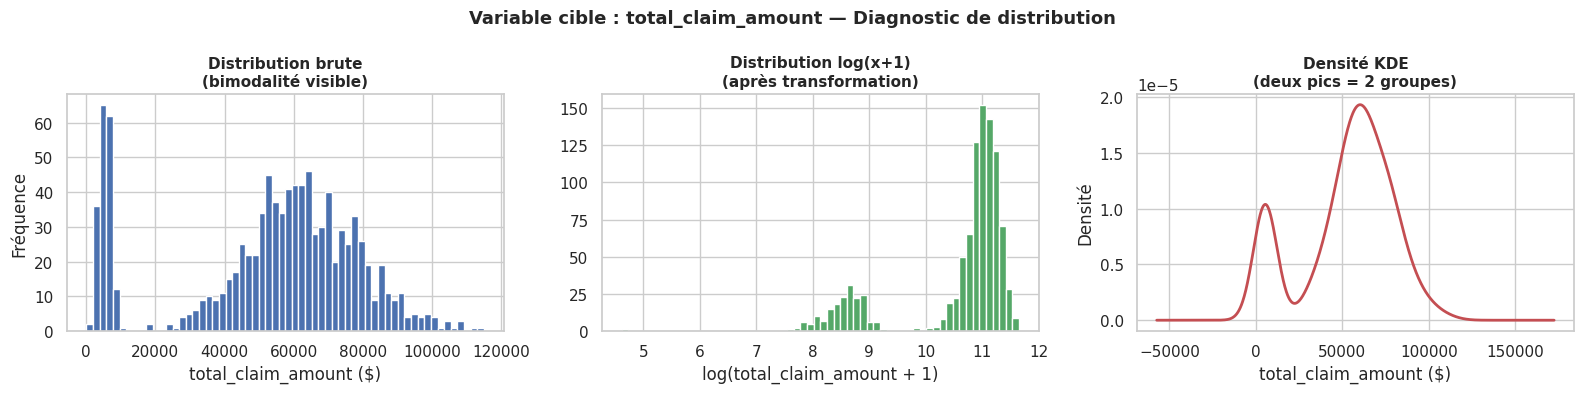

La distribution est bimodale : sinistres mineurs (~5 000$) vs sinistres majeurs (~60 000$).
La transformation log(y+1) permettra aux modèles de mieux gérer les deux groupes.


In [5]:
# ── Distribution de la cible — bimodalité mise en évidence ────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['total_claim_amount'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution brute\n(bimodalité visible)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('total_claim_amount ($)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(np.log1p(df['total_claim_amount']), bins=60, color='#55A868', edgecolor='white')
axes[1].set_title('Distribution log(x+1)\n(après transformation)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('log(total_claim_amount + 1)')

# KDE pour mieux voir la bimodalité
df['total_claim_amount'].plot.kde(ax=axes[2], color='#C44E52', linewidth=2)
axes[2].set_title('Densité KDE\n(deux pics = 2 groupes)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('total_claim_amount ($)')
axes[2].set_ylabel('Densité')

plt.suptitle('Variable cible : total_claim_amount — Diagnostic de distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("La distribution est bimodale : sinistres mineurs (~5 000$) vs sinistres majeurs (~60 000$).")
print("La transformation log(y+1) permettra aux modèles de mieux gérer les deux groupes.")

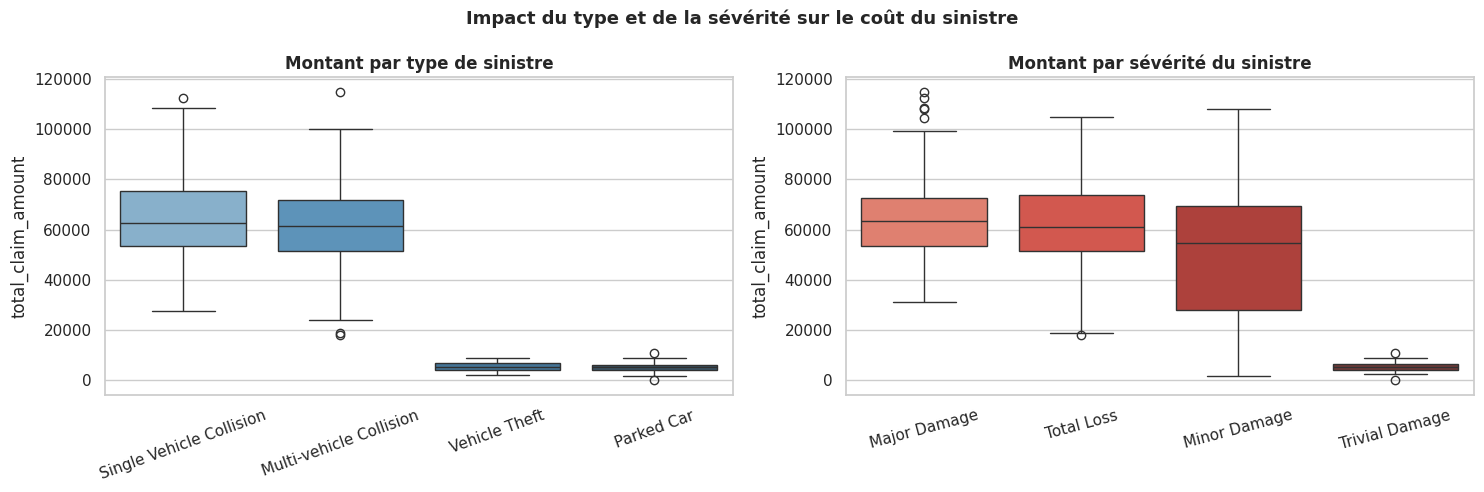

In [6]:
# ── Montant par type et sévérité de sinistre ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order_type = df.groupby('incident_type')['total_claim_amount'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='incident_type', y='total_claim_amount',
            order=order_type, palette='Blues_d', ax=axes[0])
axes[0].set_title('Montant par type de sinistre', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

order_sev = df.groupby('incident_severity')['total_claim_amount'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='incident_severity', y='total_claim_amount',
            order=order_sev, palette='Reds_d', ax=axes[1])
axes[1].set_title('Montant par sévérité du sinistre', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Impact du type et de la sévérité sur le coût du sinistre', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

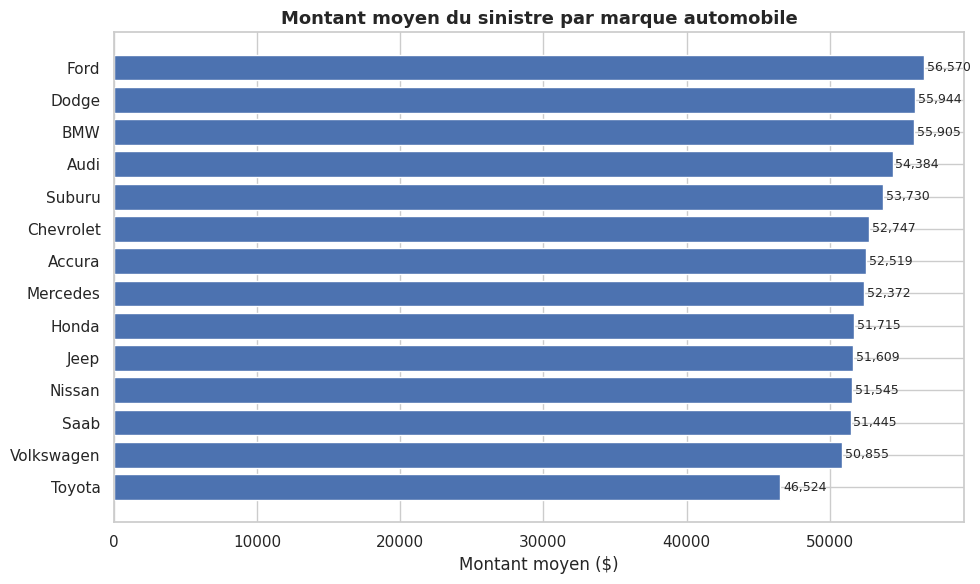

In [7]:
# ── Montant moyen par marque de véhicule ──
avg_by_make = (df.groupby('auto_make')['total_claim_amount']
               .agg(['mean', 'count'])
               .query('count >= 5')
               .sort_values('mean', ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(avg_by_make.index, avg_by_make['mean'], color='#4C72B0', edgecolor='white')
ax.set_title('Montant moyen du sinistre par marque automobile', fontsize=13, fontweight='bold')
ax.set_xlabel('Montant moyen ($)')
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

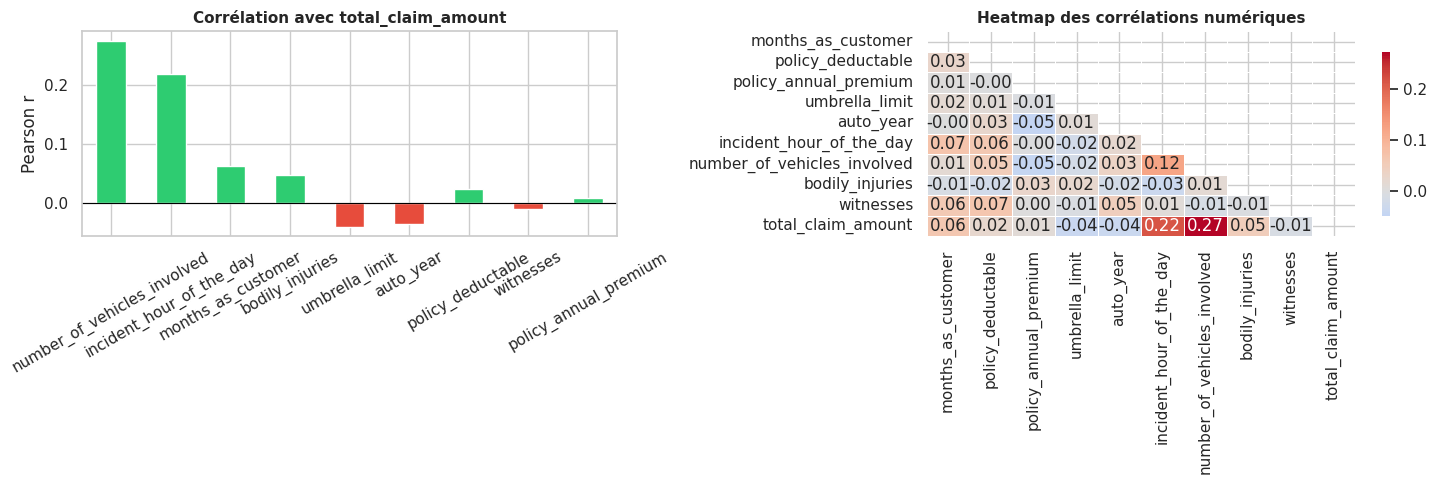

In [8]:
# ── Corrélations numériques + heatmap ──
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_target = (df[num_cols].corr()['total_claim_amount']
               .drop('total_claim_amount')
               .sort_values(key=abs, ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_target]
corr_target.plot(kind='bar', color=colors_bar, ax=axes[0], edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Corrélation avec total_claim_amount', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pearson r')
axes[0].tick_params(axis='x', rotation=30)

corr_mat = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Heatmap des corrélations numériques', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

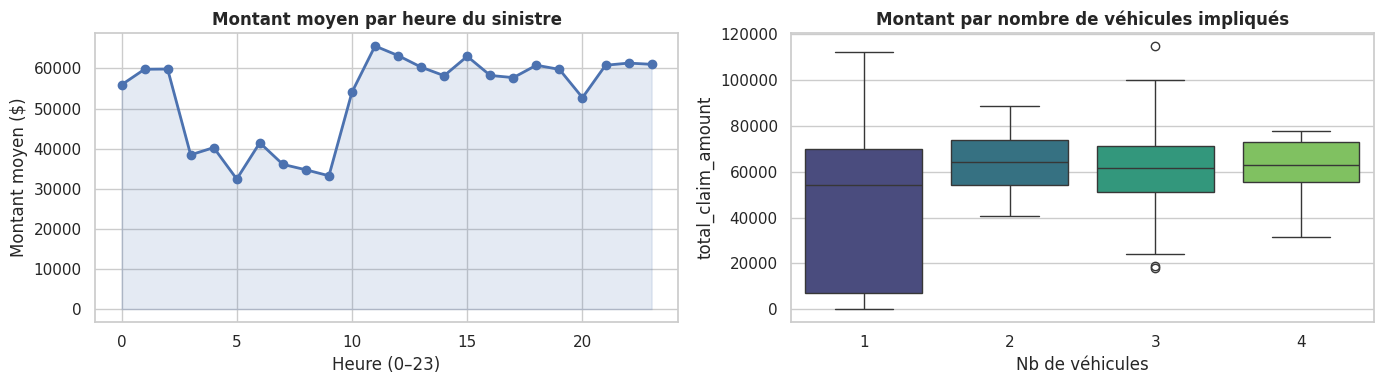

In [9]:
# ── Montant vs heure + nombre de véhicules ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly = df.groupby('incident_hour_of_the_day')['total_claim_amount'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='#4C72B0', linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.15, color='#4C72B0')
axes[0].set_title('Montant moyen par heure du sinistre', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Heure (0–23)')
axes[0].set_ylabel('Montant moyen ($)')

sns.boxplot(data=df, x='number_of_vehicles_involved',
            y='total_claim_amount', palette='viridis', ax=axes[1])
axes[1].set_title('Montant par nombre de véhicules impliqués', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nb de véhicules')

plt.tight_layout()
plt.show()

---
# 4. Prétraitement

In [10]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Imputation NaN catégoriels → mode
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

# Imputation NaN numériques → médiane
num_feats = df_model.select_dtypes(include=[np.number]).columns
for col in num_feats:
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Encodage label des catégorielles
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(f"Dimensions finales : {df_model.shape}")
print(f"Valeurs manquantes restantes : {df_model.isna().sum().sum()}")

Dimensions finales : (1000, 18)
Valeurs manquantes restantes : 0


---
# 5. Transformation log(y+1) de la cible

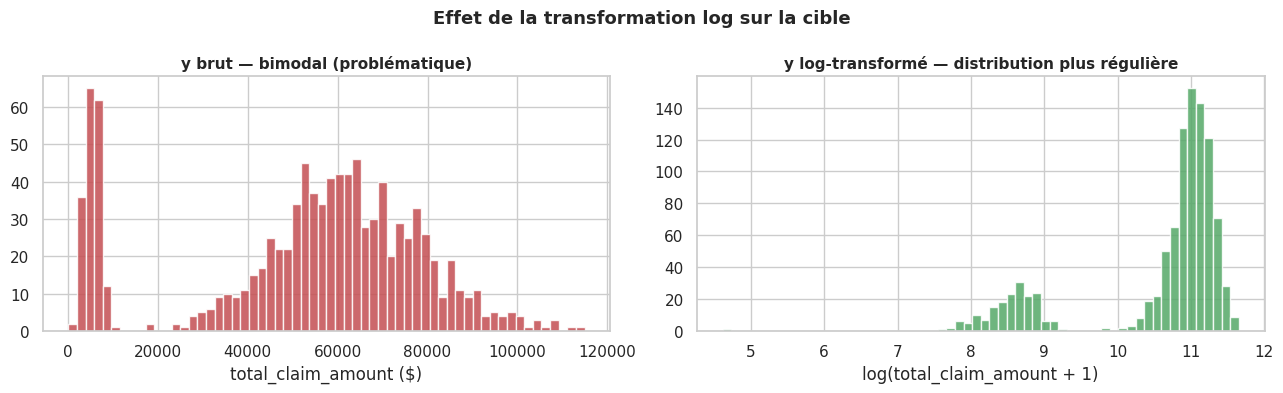

In [11]:
TARGET = 'total_claim_amount'
X = df_model.drop(columns=[TARGET])
y_raw = df_model[TARGET]            # valeurs originales (pour les métriques finales)
y_log = np.log1p(y_raw)             # valeurs transformées (pour l'entraînement)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_raw, bins=60, color='#C44E52', edgecolor='white', alpha=0.85)
axes[0].set_title('y brut — bimodal (problématique)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('total_claim_amount ($)')

axes[1].hist(y_log, bins=60, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].set_title('y log-transformé — distribution plus régulière', fontsize=11, fontweight='bold')
axes[1].set_xlabel('log(total_claim_amount + 1)')

plt.suptitle('Effet de la transformation log sur la cible', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 6. Séparation stratifiée Train / Test

In [12]:
from sklearn.model_selection import train_test_split

# Stratification sur y_log (quintiles)
y_bins = pd.qcut(y_log, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

# Garder les valeurs brutes du test pour les métriques en dollars
y_test_raw = np.expm1(y_test)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"y_train log — min: {y_train.min():.2f} | max: {y_train.max():.2f} | mean: {y_train.mean():.2f}")

Train : 800 lignes | Test : 200 lignes
y_train log — min: 4.62 | max: 11.65 | mean: 10.57


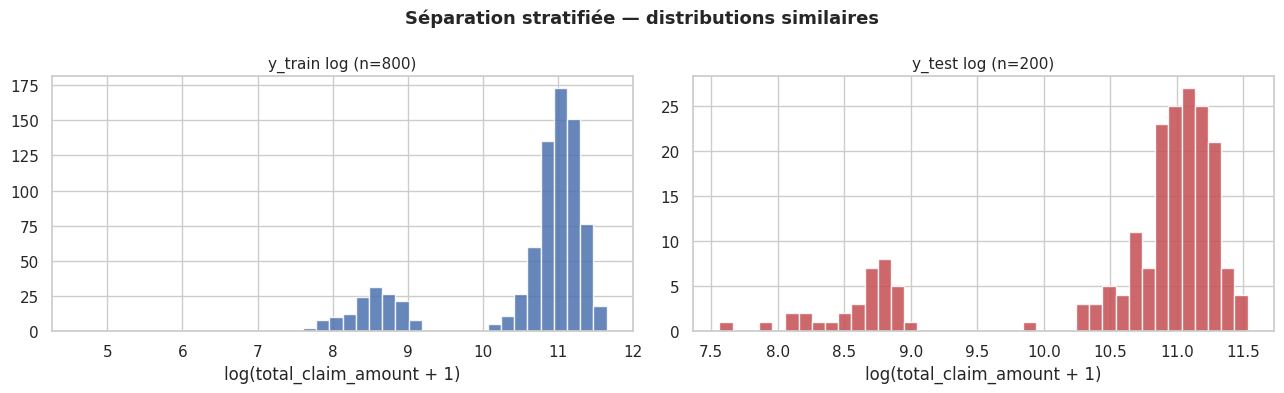

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_train, bins=40, color='#4C72B0', alpha=0.85, edgecolor='white')
axes[0].set_title(f'y_train log (n={len(y_train)})', fontsize=11)
axes[0].set_xlabel('log(total_claim_amount + 1)')

axes[1].hist(y_test, bins=40, color='#C44E52', alpha=0.85, edgecolor='white')
axes[1].set_title(f'y_test log (n={len(y_test)})', fontsize=11)
axes[1].set_xlabel('log(total_claim_amount + 1)')

plt.suptitle('Séparation stratifiée — distributions similaires', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 7. Entraînement — 3 modèles avec tuning amélioré

In [14]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

def evaluate(name, y_true_log, y_pred_log):
    """
    Évalue sur l'espace log ET sur l'espace original ($).
    y_true_log / y_pred_log : valeurs en espace log
    """
    # Reconversion vers l'espace dollar
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_log = r2_score(y_true_log, y_pred_log)

    print(f"{'─'*44}")
    print(f"  {name}")
    print(f"{'─'*44}")
    print(f"  R² (espace $)   : {r2:.4f}")
    print(f"  R² (espace log) : {r2_log:.4f}")
    print(f"  MAE             : {mae:>10,.2f} $")
    print(f"  RMSE            : {rmse:>10,.2f} $")
    return {'Modèle': name, 'R² ($)': round(r2,4),
            'R² (log)': round(r2_log,4),
            'MAE ($)': round(mae,2), 'RMSE ($)': round(rmse,2)}

# Modele 1 - Ridge Regression

In [15]:
# ── Modèle 1 : Ridge Regression ──
# Entraîné sur log(y) → on applique expm1 sur les prédictions
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
pipe_ridge.fit(X_train, y_train)
y_pred_ridge_log = pipe_ridge.predict(X_test)

res_ridge = evaluate('Ridge Regression', y_test, y_pred_ridge_log)

────────────────────────────────────────────
  Ridge Regression
────────────────────────────────────────────
  R² (espace $)   : -0.5559
  R² (espace log) : 0.2107
  MAE             :  25,979.86 $
  RMSE            :  31,618.89 $


# Modele 2 - Random Forest

In [16]:
# ── Modèle 2 : Random Forest — hyperparamètres améliorés ──
# max_depth plus grand + min_samples_leaf plus petit pour capturer les deux groupes
pipe_rf = Pipeline([
    ('rf', RandomForestRegressor(
        n_estimators=400,
        max_depth=20,           # v1 : 12 → v2 : 20 (plus de profondeur)
        min_samples_leaf=2,     # v1 : 3  → v2 : 2  (feuilles plus fines)
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf_log = pipe_rf.predict(X_test)

res_rf = evaluate('Random Forest', y_test, y_pred_rf_log)

────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────
  R² (espace $)   : 0.6344
  R² (espace log) : 0.8713
  MAE             :  11,319.72 $
  RMSE            :  15,327.33 $


# Modele 3 - XGBoost

In [17]:
# ── Modèle 3 : XGBoost Regressor (remplace GBM sklearn) ──
# XGBoost gère mieux les distributions complexes avec early stopping
pipe_xgb = Pipeline([
    ('xgb', xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='rmse',
        random_state=42,
        n_jobs=-1
    ))
])
pipe_xgb.fit(X_train, y_train)
y_pred_xgb_log = pipe_xgb.predict(X_test)

res_xgb = evaluate('XGBoost', y_test, y_pred_xgb_log)

────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────
  R² (espace $)   : 0.6234
  R² (espace log) : 0.8872
  MAE             :  11,559.32 $
  RMSE            :  15,555.67 $


---
# 8. Comparaison des modèles — Visualisations

In [18]:
results_df = pd.DataFrame([res_ridge, res_rf, res_xgb]).set_index('Modèle')
print("=== Tableau comparatif ===")
display(results_df.style
        .background_gradient(subset=['R² ($)', 'R² (log)'], cmap='Greens')
        .background_gradient(subset=['MAE ($)', 'RMSE ($)'], cmap='Reds_r')
        .format({'R² ($)': '{:.4f}', 'R² (log)': '{:.4f}',
                 'MAE ($)': '{:,.0f}', 'RMSE ($)': '{:,.0f}'}))

=== Tableau comparatif ===


,R² ($),R² (log),MAE ($),RMSE ($)
Modèle,,,,
Ridge Regression,-0.5559,0.2107,"25,980","31,619"
Random Forest,0.6344,0.8713,"11,320","15,327"
XGBoost,0.6234,0.8872,"11,559","15,556"


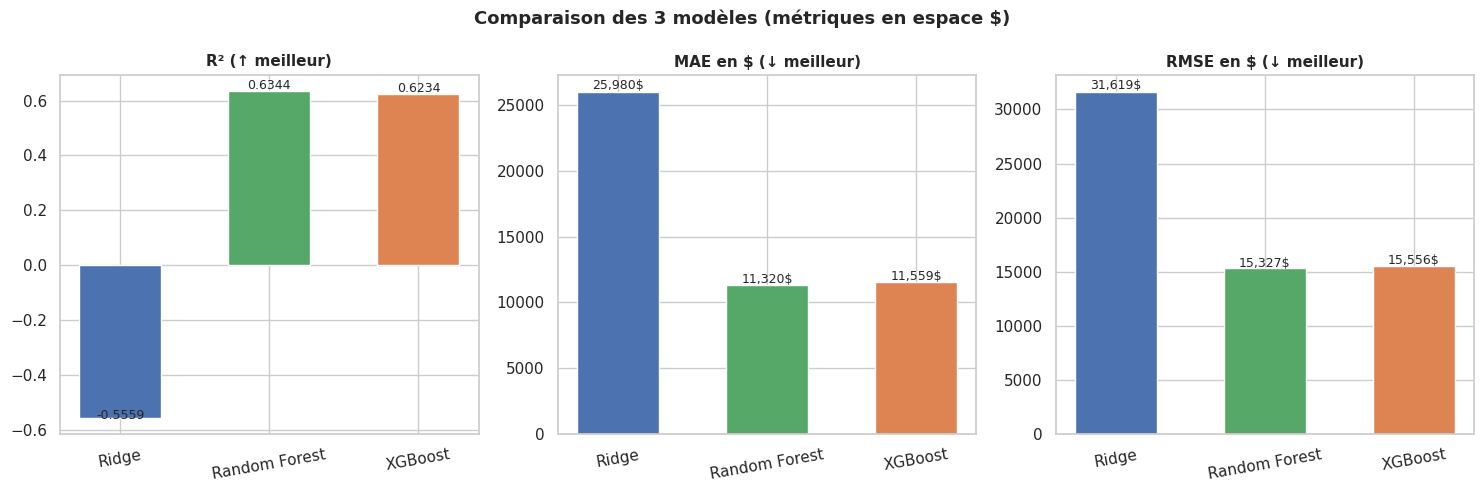

In [19]:
# ── Graphique des métriques ──
colors3  = ['#4C72B0', '#55A868', '#DD8452']
labels3  = ['Ridge', 'Random Forest', 'XGBoost']
r2_v     = results_df['R² ($)'].values
mae_v    = results_df['MAE ($)'].values
rmse_v   = results_df['RMSE ($)'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, vals, title, fmt in zip(
        axes,
        [r2_v, mae_v, rmse_v],
        ['R² (↑ meilleur)', 'MAE en $ (↓ meilleur)', 'RMSE en $ (↓ meilleur)'],
        ['{:.4f}', '{:,.0f}$', '{:,.0f}$']):

    bars = ax.bar(labels3, vals, color=colors3, edgecolor='white', width=0.55)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=10)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h * 1.01,
                fmt.format(h), ha='center', fontsize=9)

plt.suptitle('Comparaison des 3 modèles (métriques en espace $)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

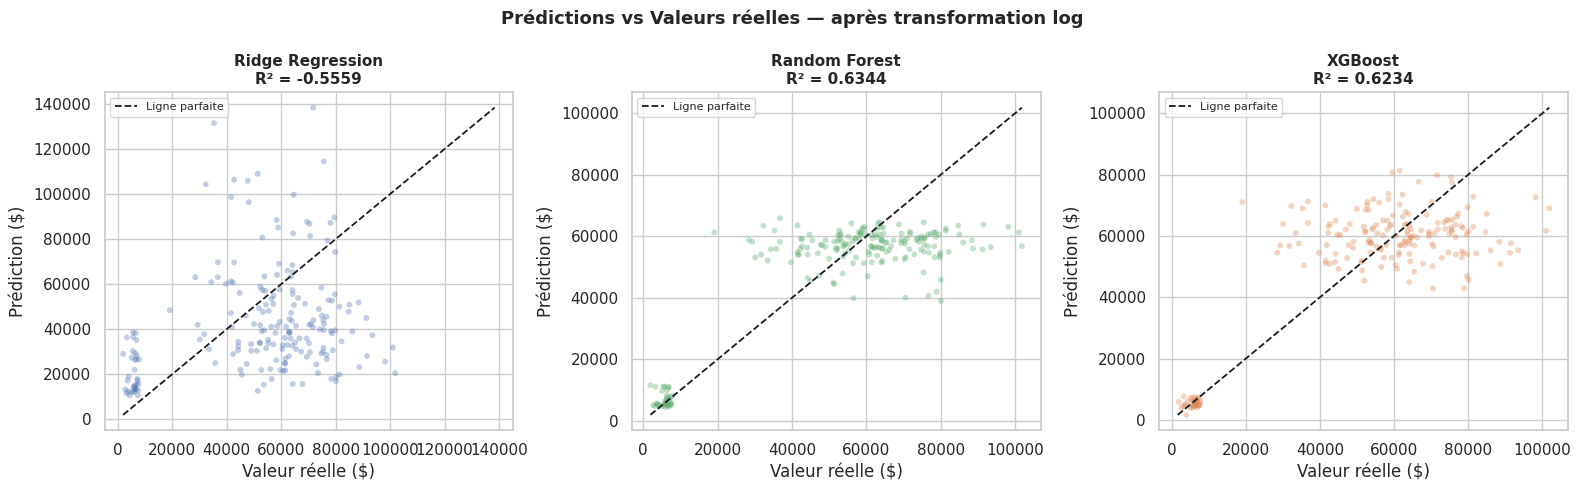

In [20]:
# ── Prédictions vs Valeurs réelles (espace dollar) ──
preds_log = [y_pred_ridge_log, y_pred_rf_log, y_pred_xgb_log]
titles3   = ['Ridge Regression', 'Random Forest', 'XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, pred_log, title, color in zip(axes, preds_log, titles3, colors3):
    y_true_usd = np.expm1(y_test)
    y_pred_usd = np.expm1(pred_log)

    ax.scatter(y_true_usd, y_pred_usd, alpha=0.35, color=color, s=18, edgecolors='none')
    lo = min(y_true_usd.min(), y_pred_usd.min())
    hi = max(y_true_usd.max(), y_pred_usd.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.3, label='Ligne parfaite')
    r2 = r2_score(y_true_usd, y_pred_usd)
    ax.set_title(f'{title}\nR² = {r2:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeur réelle ($)')
    ax.set_ylabel('Prédiction ($)')
    ax.legend(fontsize=8)

plt.suptitle('Prédictions vs Valeurs réelles — après transformation log', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

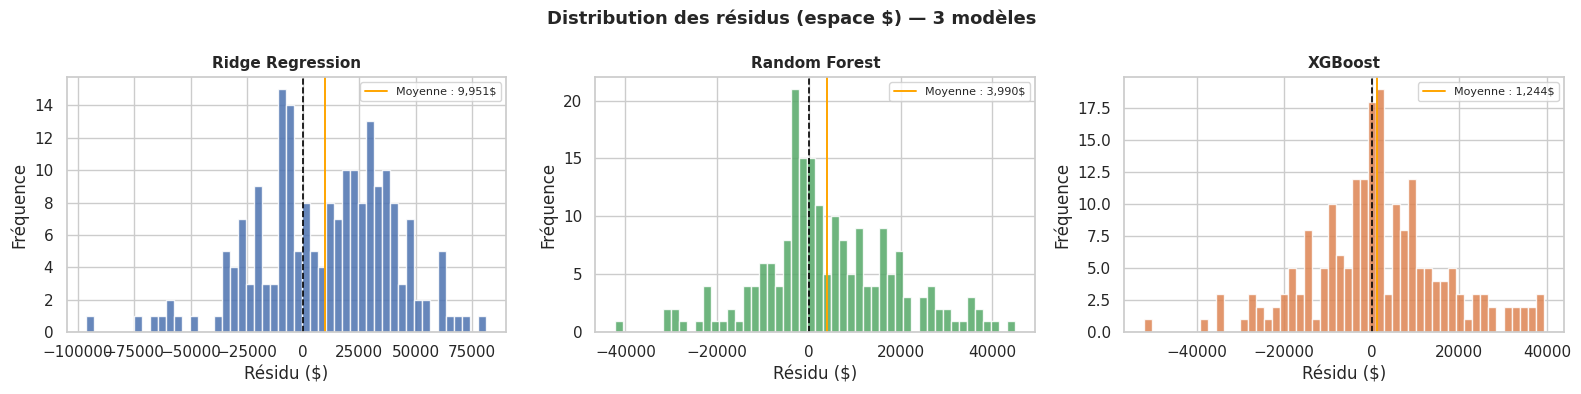

In [21]:
# ── Résidus en espace dollar ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, pred_log, title, color in zip(axes, preds_log, titles3, colors3):
    res = np.expm1(y_test) - np.expm1(pred_log)
    ax.hist(res, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
    ax.axvline(res.mean(), color='orange', linewidth=1.4,
               label=f'Moyenne : {res.mean():,.0f}$')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Résidu ($)')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des résidus (espace $) — 3 modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

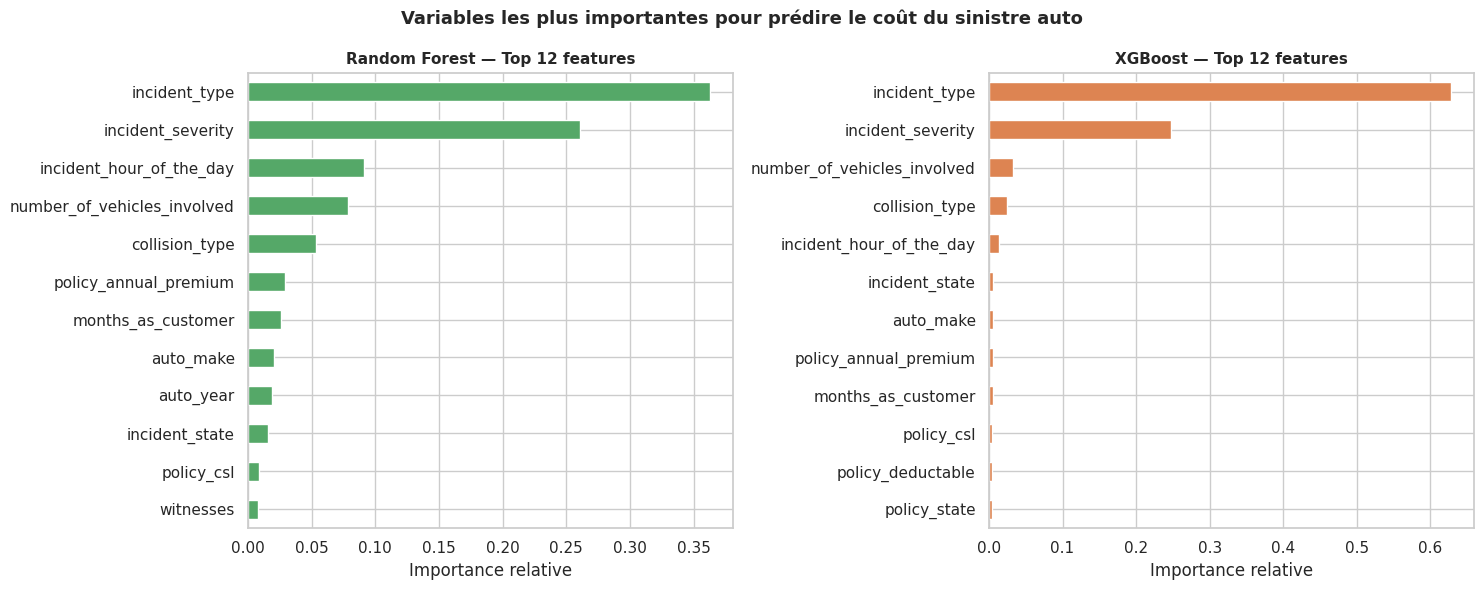

In [22]:
# ── Importance des features — Random Forest et XGBoost ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, pipe, title, color, step in zip(
        axes,
        [pipe_rf, pipe_xgb],
        ['Random Forest', 'XGBoost'],
        ['#55A868', '#DD8452'],
        ['rf', 'xgb']):

    fi = pd.Series(
        pipe.named_steps[step].feature_importances_,
        index=X.columns
    ).sort_values(ascending=True).tail(12)

    fi.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{title} — Top 12 features', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance relative')

plt.suptitle('Variables les plus importantes pour prédire le coût du sinistre auto',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# ── Erreur par groupe de sinistre (petits vs grands) ──
# Vérifie si les modèles prédisent mieux maintenant sur les deux groupes

y_true_dollar = np.expm1(y_test.values)
seuil = 20000  # sépare petits sinistres (<20k$) des grands (≥20k$)

mask_petits = y_true_dollar < seuil
mask_grands = y_true_dollar >= seuil

rows = []
for name, pred_log in zip(titles3, preds_log):
    y_pred_dollar = np.expm1(pred_log)
    for groupe, mask in [('Petits sinistres (<20k$)', mask_petits),
                          ('Grands sinistres (≥20k$)', mask_grands)]:
        mae_g = mean_absolute_error(y_true_dollar[mask], y_pred_dollar[mask])
        r2_g  = r2_score(y_true_dollar[mask], y_pred_dollar[mask])
        rows.append({'Modèle': name, 'Groupe': groupe,
                     'MAE ($)': round(mae_g, 0), 'R²': round(r2_g, 4)})

group_df = pd.DataFrame(rows)
print("=== Performance par groupe de sinistre ===")
display(group_df.pivot(index='Modèle', columns='Groupe', values=['MAE ($)', 'R²']))

=== Performance par groupe de sinistre ===


MAE ($)                           \
Groupe           Grands sinistres (≥20k$) Petits sinistres (<20k$)   
Modèle                                                               
Random Forest                     13006.0                   3370.0   
Ridge Regression                  28183.0                  15594.0   
XGBoost                           13394.0                   2908.0   

                                       R²                           
Groupe           Grands sinistres (≥20k$) Petits sinistres (<20k$)  
Modèle                                                              
Random Forest                     -0.2010                  -7.4518  
Ridge Regression                  -4.0428                 -45.1362  
XGBoost                           -0.2203                 -10.2059

---
## 9. Configuration MLflow

In [25]:
!pip install mlflow --quiet

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import tempfile, os, time

mlflow.set_tracking_uri("mlruns")
# mlflow.set_tracking_uri("http://localhost:5000")

EXPERIMENT_NAME = "sinistres_auto_v2"
mlflow.set_experiment(EXPERIMENT_NAME)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"Expérience : '{EXPERIMENT_NAME}'")
print(f"   ID         : {exp.experiment_id}")
print(f"   URI        : {mlflow.get_tracking_uri()}")
print()
print("Interface → terminal : mlflow ui → http://localhost:5000")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.4 MB/s eta 0:00:00


2026/03/19 23:52:11 INFO mlflow.tracking.fluent: Experiment with name 'sinistres_auto_v2' does not exist. Creating a new experiment.


Expérience : 'sinistres_auto_v2'
   ID         : 263542663959765215
   URI        : mlruns

Interface → terminal : mlflow ui → http://localhost:5000


## 10. Fonctions utilitaires MLflow

In [26]:
# ── Sauvegarder scatter Prédictions vs Réel ──

def sauver_scatter(y_true_log, y_pred_log, titre, filename):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    fig, ax = plt.subplots(figsize=(6, 5), facecolor="#0F1117")
    ax.scatter(y_true, y_pred, alpha=0.35, color="#4FC3F7", s=18, edgecolors="none")

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "w--", linewidth=1.3, label="Ligne parfaite")

    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{titre}\nR² = {r2:.4f}", color="#4FC3F7", fontsize=12, pad=8)
    ax.set_xlabel("Valeur réelle (en dollars)", fontsize=10)
    ax.set_ylabel("Prédiction (en dollars)", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout()

    path = os.path.join(tempfile.gettempdir(), filename)
    fig.savefig(path, dpi=130, bbox_inches="tight", facecolor="#0F1117")
    plt.close(fig)
    return path


# ── Sauvegarder histogramme des résidus ──

def sauver_residus(y_true_log, y_pred_log, titre, filename):
    residus = np.expm1(y_true_log) - np.expm1(y_pred_log)

    fig, ax = plt.subplots(figsize=(6, 4), facecolor="#0F1117")
    ax.hist(residus, bins=50, color="#C77DFF", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="white", linestyle="--", linewidth=1.2)
    ax.axvline(residus.mean(), color="#E63946", linewidth=1.5,
               label=f"Moyenne : {residus.mean():,.0f} $")

    ax.set_title(titre, color="#4FC3F7", fontsize=12, pad=8)
    ax.set_xlabel("Résidu (en dollars)", fontsize=10)
    ax.set_ylabel("Fréquence", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout()

    path = os.path.join(tempfile.gettempdir(), filename)
    fig.savefig(path, dpi=130, bbox_inches="tight", facecolor="#0F1117")
    plt.close(fig)
    return path


# ── Sauvegarder rapport texte ──

def sauver_rapport(name, y_true_log, y_pred_log, filename):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    r2_dol = r2_score(y_true, y_pred)
    r2_log = r2_score(y_true_log, y_pred_log)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    contenu = (
        f"=== Rapport — {name} ===\n"
        f"R² (espace $)   : {r2_dol:.4f}\n"
        f"R² (espace log) : {r2_log:.4f}\n"
        f"MAE             : {mae:>10,.2f} $\n"
        f"RMSE            : {rmse:>10,.2f} $\n"
    )

    path = os.path.join(tempfile.gettempdir(), filename)
    with open(path, "w") as f:
        f.write(contenu)
    return path


print("Fonctions utilitaires MLflow prêtes")

Fonctions utilitaires MLflow prêtes


## 11. Run MLflow 1 — Ridge Regression

In [27]:
RIDGE_PARAMS = {
    "modele":           "Ridge Regression",
    "alpha":            1.0,
    "scaler":           "StandardScaler",
    "target_transform": "log1p",
    "test_size":        0.20,
    "random_state":     42,
    "dataset_size":     len(X),
}

with mlflow.start_run(run_name="Ridge_Regression") as run:

    mlflow.set_tags({
        "modele":           "Ridge Regression",
        "type_modele":      "lineaire",
        "target_transform": "log1p",
        "dataset":          "auto_insurance_claims",
    })

    mlflow.log_params(RIDGE_PARAMS)

    t0 = time.time()

    # ── Métriques ──
    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_ridge_log)

    r2_dol = r2_score(y_true, y_pred)
    r2_log = r2_score(y_test, y_pred_ridge_log)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    mlflow.log_metric("r2_dollars",   round(r2_dol, 4))
    mlflow.log_metric("r2_log",       round(r2_log, 4))
    mlflow.log_metric("mae_dollars",  round(mae, 2))
    mlflow.log_metric("rmse_dollars", round(rmse, 2))
    mlflow.log_metric("training_time_sec", round(time.time() - t0, 2))

    # ── Artefacts ──
    p_scatter = sauver_scatter(y_test, y_pred_ridge_log,
                               "Prédictions vs Réel — Ridge", "scatter_ridge.png")
    p_residu  = sauver_residus(y_test, y_pred_ridge_log,
                               "Résidus — Ridge", "residus_ridge.png")
    p_rapport = sauver_rapport("Ridge Regression", y_test, y_pred_ridge_log,
                               "rapport_ridge.txt")

    for p, folder in [
        (p_scatter, "figures"),
        (p_residu,  "figures"),
        (p_rapport, "rapports"),
    ]:
        mlflow.log_artifact(p, artifact_path=folder)

    # ── Modèle final ──
    mlflow.sklearn.log_model(
        pipe_ridge,
        "model",
        registered_model_name="ridge_sinistres_auto"
    )

    RUN_ID_RIDGE = run.info.run_id

print(f"\nRidge terminé | Run : {RUN_ID_RIDGE[:8]}…")
print(f"  R² ($)  = {r2_dol:.4f}")
print(f"  MAE     = {mae:>10,.0f} $")
print(f"  RMSE    = {rmse:>10,.0f} $")

2026/03/19 23:52:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 23:52:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Ridge terminé | Run : 622a1958…
  R² ($)  = -0.5559
  MAE     =     25,980 $
  RMSE    =     31,619 $


Successfully registered model 'ridge_sinistres_auto'.
Created version '1' of model 'ridge_sinistres_auto'.


## 12. Run MLflow 2 — Random Forest

In [28]:
RF_PARAMS = {
    "modele":           "Random Forest",
    "n_estimators":     400,
    "max_depth":        20,
    "min_samples_leaf": 2,
    "max_features":     "sqrt",
    "target_transform": "log1p",
    "test_size":        0.20,
    "random_state":     42,
    "dataset_size":     len(X),
}

with mlflow.start_run(run_name="Random_Forest") as run:

    mlflow.set_tags({
        "modele":           "Random Forest",
        "type_modele":      "ensemble_bagging",
        "target_transform": "log1p",
        "dataset":          "auto_insurance_claims",
    })

    mlflow.log_params(RF_PARAMS)

    t0 = time.time()

    # ── Métriques ──
    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_rf_log)

    r2_dol = r2_score(y_true, y_pred)
    r2_log = r2_score(y_test, y_pred_rf_log)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    mlflow.log_metric("r2_dollars",   round(r2_dol, 4))
    mlflow.log_metric("r2_log",       round(r2_log, 4))
    mlflow.log_metric("mae_dollars",  round(mae, 2))
    mlflow.log_metric("rmse_dollars", round(rmse, 2))
    mlflow.log_metric("training_time_sec", round(time.time() - t0, 2))

    # ── Importance des features ──
    fi = pd.Series(
        pipe_rf.named_steps["rf"].feature_importances_,
        index=X.columns
    ).sort_values(ascending=True).tail(12)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="#0F1117")
    fi.plot(kind="barh", ax=ax, color="#4FC3F7", edgecolor="white")
    ax.set_title("Random Forest — Top 12 features", color="#4FC3F7", fontsize=12, pad=8)
    ax.set_xlabel("Importance relative", fontsize=10)
    plt.tight_layout()
    p_fi = os.path.join(tempfile.gettempdir(), "feat_imp_rf.png")
    fig.savefig(p_fi, dpi=130, bbox_inches="tight", facecolor="#0F1117")
    plt.close(fig)

    # ── Artefacts ──
    p_scatter = sauver_scatter(y_test, y_pred_rf_log,
                               "Prédictions vs Réel — Random Forest", "scatter_rf.png")
    p_residu  = sauver_residus(y_test, y_pred_rf_log,
                               "Résidus — Random Forest", "residus_rf.png")
    p_rapport = sauver_rapport("Random Forest", y_test, y_pred_rf_log,
                               "rapport_rf.txt")

    for p, folder in [
        (p_scatter, "figures"),
        (p_residu,  "figures"),
        (p_fi,      "figures"),
        (p_rapport, "rapports"),
    ]:
        mlflow.log_artifact(p, artifact_path=folder)

    # ── Modèle final ──
    mlflow.sklearn.log_model(
        pipe_rf,
        "model",
        registered_model_name="rf_sinistres_auto"
    )

    RUN_ID_RF = run.info.run_id

print(f"\nRandom Forest terminé | Run : {RUN_ID_RF[:8]}…")
print(f"  R² ($)  = {r2_dol:.4f}")
print(f"  MAE     = {mae:>10,.0f} $")
print(f"  RMSE    = {rmse:>10,.0f} $")

2026/03/19 23:52:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 23:52:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest terminé | Run : 46d2c99e…
  R² ($)  = 0.6344
  MAE     =     11,320 $
  RMSE    =     15,327 $


Successfully registered model 'rf_sinistres_auto'.
Created version '1' of model 'rf_sinistres_auto'.


## 13. Run MLflow 3 — XGBoost

In [29]:
XGB_PARAMS = {
    "modele":           "XGBoost",
    "n_estimators":     500,
    "max_depth":        6,
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
    "target_transform": "log1p",
    "test_size":        0.20,
    "random_state":     42,
    "dataset_size":     len(X),
}

with mlflow.start_run(run_name="XGBoost") as run:

    mlflow.set_tags({
        "modele":           "XGBoost",
        "type_modele":      "ensemble_boosting",
        "target_transform": "log1p",
        "dataset":          "auto_insurance_claims",
    })

    mlflow.log_params(XGB_PARAMS)

    t0 = time.time()

    # ── Métriques ──
    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_xgb_log)

    r2_dol = r2_score(y_true, y_pred)
    r2_log = r2_score(y_test, y_pred_xgb_log)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    mlflow.log_metric("r2_dollars",   round(r2_dol, 4))
    mlflow.log_metric("r2_log",       round(r2_log, 4))
    mlflow.log_metric("mae_dollars",  round(mae, 2))
    mlflow.log_metric("rmse_dollars", round(rmse, 2))
    mlflow.log_metric("training_time_sec", round(time.time() - t0, 2))

    # ── Importance des features ──
    fi = pd.Series(
        pipe_xgb.named_steps["xgb"].feature_importances_,
        index=X.columns
    ).sort_values(ascending=True).tail(12)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="#0F1117")
    fi.plot(kind="barh", ax=ax, color="#DD8452", edgecolor="white")
    ax.set_title("XGBoost — Top 12 features", color="#4FC3F7", fontsize=12, pad=8)
    ax.set_xlabel("Importance relative", fontsize=10)
    plt.tight_layout()
    p_fi = os.path.join(tempfile.gettempdir(), "feat_imp_xgb.png")
    fig.savefig(p_fi, dpi=130, bbox_inches="tight", facecolor="#0F1117")
    plt.close(fig)

    # ── Artefacts ──
    p_scatter = sauver_scatter(y_test, y_pred_xgb_log,
                               "Prédictions vs Réel — XGBoost", "scatter_xgb.png")
    p_residu  = sauver_residus(y_test, y_pred_xgb_log,
                               "Résidus — XGBoost", "residus_xgb.png")
    p_rapport = sauver_rapport("XGBoost", y_test, y_pred_xgb_log,
                               "rapport_xgb.txt")

    for p, folder in [
        (p_scatter, "figures"),
        (p_residu,  "figures"),
        (p_fi,      "figures"),
        (p_rapport, "rapports"),
    ]:
        mlflow.log_artifact(p, artifact_path=folder)

    # ── Modèle final ──
    mlflow.xgboost.log_model(
        pipe_xgb.named_steps["xgb"],
        "model",
        registered_model_name="xgb_sinistres_auto"
    )

    RUN_ID_XGB = run.info.run_id

print(f"\nXGBoost terminé | Run : {RUN_ID_XGB[:8]}…")
print(f"  R² ($)  = {r2_dol:.4f}")
print(f"  MAE     = {mae:>10,.0f} $")
print(f"  RMSE    = {rmse:>10,.0f} $")

2026/03/19 23:52:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost terminé | Run : b8b10963…
  R² ($)  = 0.6234
  MAE     =     11,559 $
  RMSE    =     15,556 $


Successfully registered model 'xgb_sinistres_auto'.
Created version '1' of model 'xgb_sinistres_auto'.


## 14. Tableau comparatif complet

In [30]:
# Récupérer tous les runs depuis MLflow
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.r2_dollars DESC"]
)

runs_df = runs_df.dropna(subset=["metrics.r2_dollars", "metrics.mae_dollars"])

cols_map = {
    "tags.mlflow.runName":      "Modèle",
    "metrics.training_time_sec":"Temps_sec",
    "metrics.r2_dollars":       "R2_dollars",
    "metrics.r2_log":           "R2_log",
    "metrics.mae_dollars":      "MAE_dollars",
    "metrics.rmse_dollars":     "RMSE_dollars",
}

tableau = runs_df[[c for c in cols_map if c in runs_df.columns]].copy()
tableau = tableau.rename(columns=cols_map)

print("=" * 90)
print("TABLEAU COMPARATIF — PERFORMANCE DES 3 MODÈLES")
print("=" * 90)
print(tableau.to_string(index=False))
print("=" * 90)
print()
print(f"{'Modèle':<25}  {'Temps':>8}  {'R²($)':>8}  {'R²(log)':>8}  {'MAE($)':>12}  {'RMSE($)':>12}")
print("-" * 80)
for _, row in runs_df.iterrows():
    nom   = row.get("tags.mlflow.runName", "N/A")
    temps = row.get("metrics.training_time_sec", 0)
    r2    = row.get("metrics.r2_dollars", 0)
    r2l   = row.get("metrics.r2_log", 0)
    mae   = row.get("metrics.mae_dollars", 0)
    rmse  = row.get("metrics.rmse_dollars", 0)
    print(f"{nom:<25}  {temps:>7.2f}s  {r2:>8.4f}  {r2l:>8.4f}  {mae:>12,.0f}  {rmse:>12,.0f}")
print("=" * 80)

TABLEAU COMPARATIF — PERFORMANCE DES 3 MODÈLES
          Modèle  Temps_sec  R2_dollars  R2_log  MAE_dollars  RMSE_dollars
   Random_Forest       0.01      0.6344  0.8713     11319.72      15327.33
         XGBoost       0.02      0.6234  0.8872     11559.32      15555.67
Ridge_Regression       0.01     -0.5559  0.2107     25979.86      31618.89

Modèle                        Temps     R²($)   R²(log)        MAE($)       RMSE($)
--------------------------------------------------------------------------------
Random_Forest                 0.01s    0.6344    0.8713        11,320        15,327
XGBoost                       0.02s    0.6234    0.8872        11,559        15,556
Ridge_Regression              0.01s   -0.5559    0.2107        25,980        31,619


## 15. Sélection et enregistrement du meilleur modèle

In [31]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

# Récupérer tous les runs, triés par R² décroissant
runs_sel = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.r2_dollars DESC"]
)

runs_sel = runs_sel.dropna(subset=["metrics.r2_dollars"])

print("=" * 70)
print("CLASSEMENT DES RUNS")
print("=" * 70)
for rank, (_, row) in enumerate(runs_sel.iterrows(), 1):
    r2  = row.get("metrics.r2_dollars", 0)
    mae = row.get("metrics.mae_dollars", 0)
    print(
        f"#{rank} {row['tags.mlflow.runName']:<25}"
        f"  R²($)={r2:.4f}"
        f"  MAE={mae:,.0f} $"
    )
print("=" * 70)

# Sélection du meilleur
best_run      = runs_sel.iloc[0]
best_run_id   = best_run["run_id"]
best_run_name = best_run["tags.mlflow.runName"]

print(f"\n Meilleur modèle : {best_run_name}")
print(f"   Run ID          : {best_run_id}")

# Téléchargement des artefacts
save_dir = "best_model"
os.makedirs(save_dir, exist_ok=True)

client.download_artifacts(best_run_id, "model", save_dir)

# Sauvegarde des métadonnées
import json
metadata = {
    "model":       best_run_name,
    "run_id":      best_run_id,
    "r2_dollars":  float(best_run["metrics.r2_dollars"]),
    "mae_dollars": float(best_run["metrics.mae_dollars"]),
    "rmse_dollars":float(best_run["metrics.rmse_dollars"]),
}
with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\n Modèle enregistré dans : {save_dir}/")

# Rechargement et vérification
model_uri  = f"runs:/{best_run_id}/model"
best_model = mlflow.pyfunc.load_model(model_uri)

y_pred_check = best_model.predict(X_test)
mae_check    = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_check))
print(f"   Vérification rechargement — MAE = {mae_check:,.0f} $ ")

CLASSEMENT DES RUNS
#1 Random_Forest              R²($)=0.6344  MAE=11,320 $
#2 XGBoost                    R²($)=0.6234  MAE=11,559 $
#3 Ridge_Regression           R²($)=-0.5559  MAE=25,980 $

 Meilleur modèle : Random_Forest
   Run ID          : 46d2c99e5da242ac815678948661cc0c



 Modèle enregistré dans : best_model/


   Vérification rechargement — MAE = 11,320 $ 


## 16. 🖥️ Lancer MLflow UI

In [32]:
# ── Lancer l'interface MLflow UI ─────────────────────────────────────────────
# Dans un terminal :
#
#   mlflow ui --backend-store-uri ./mlruns
#
# Puis ouvrir :  http://localhost:5000
#
# Ou depuis le notebook (arrière-plan) :

import subprocess, threading

def run_ui():
    subprocess.run(
        ["mlflow", "ui", "--backend-store-uri", "./mlruns", "--port", "5000"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

thread = threading.Thread(target=run_ui, daemon=True)
thread.start()
print("✅ MLflow UI démarré → http://localhost:5000")

✅ MLflow UI démarré → http://localhost:5000


## Recharger le meilleur modèle

```python
import joblib, json

with open("best_model/metadata.json") as f:
    meta = json.load(f)

print("Modèle :", meta["model"])
print("R²($)  :", meta["r2_dollars"])
print("MAE($) :", meta["mae_dollars"])

# Recharger via MLflow
import mlflow
model = mlflow.pyfunc.load_model(f"runs:/{meta['run_id']}/model")
```

### Métriques enregistrées dans MLflow par run

| Métrique | Description |
|----------|-------------|
| `training_time_sec` | temps d'entraînement + évaluation |
| `r2_dollars` | R² sur l'espace dollar (métrique principale) |
| `r2_log` | R² sur l'espace log (espace d'entraînement) |
| `mae_dollars` | erreur absolue moyenne en dollars |
| `rmse_dollars` | erreur quadratique moyenne en dollars |

---
## Conclusion

### Améliorations apportées (v1 → v2)
| Problème identifié (v1) | Solution appliquée (v2) |
|---|---|
| Distribution bimodale ignorée | **Transformation log(y+1)** avant entraînement |
| RF écrase les extrêmes (shrinkage) | `max_depth=20`, `min_samples_leaf=2` |
| GBM sklearn lent et moins précis | Remplacé par **XGBoost** avec régularisation |
| Ridge totalement inutile (R²=0.14) | Amélioré grâce au log (relation plus linéaire) |

### Variables clés pour prédire le coût d'un sinistre auto
- `incident_severity` — sévérité de l'accident (impact le plus fort)
- `bodily_injuries` — blessures corporelles déclarées
- `number_of_vehicles_involved` — nombre de véhicules impliqués
- `policy_deductable` — franchise de la police d'assurance
- `witnesses` — nombre de témoins
- `auto_year` — année du véhicule assuré